# Network Intrusion Detection on NSL-KDD — A Critical Reproduction Study

**Domain:** Intrusion Detection Systems · **Dataset:** NSL-KDD (KDDTrain+ / KDDTest+)

---

### Source under evaluation

> **Mamcose — *NSL-KDD Network Intrusion Detection***
> https://github.com/Mamcose/NSL-KDD-Network-Intrusion-Detection

This widely-referenced tutorial loads the official NSL-KDD train and test files, splits
the attacks into the four standard categories (DoS, Probe, R2L, U2R), and trains Random
Forest, K-Nearest-Neighbours and a linear SVM. It evaluates each model with **10-fold
cross-validation on same-distribution data** and reports **accuracies up to ~0.998**
(Random Forest highest), concluding that machine learning detects network intrusions
almost perfectly.

### What this notebook does

We reproduce the pipeline but ask whether that near-perfect accuracy reflects real
detection ability. The decisive question for NSL-KDD is the *evaluation protocol*:

1. The benchmark ships a dedicated test file, **KDDTest+**, that deliberately contains
   **attack types never seen in training**. Cross-validating inside one distribution
   hides this. What happens under the intended train→test protocol?
2. Is accuracy meaningful when two of the four attack families (R2L, U2R) are extremely
   rare?
3. Are there dead features, redundancy, or hidden preprocessing?
4. Is a 2009 dataset of late-1990s traffic a sound basis for a deployable detector?

## 0. Setup and configuration

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, matthews_corrcoef, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve, classification_report)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
BETA = 2.0                 # F-beta weights recall over precision (a miss is costly)
OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
FIG = OUT / "figures"; FIG.mkdir(exist_ok=True)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RESULTS_OFFICIAL, RESULTS_CV, FINDINGS = {}, {}, {}

# The 41 NSL-KDD features + label + difficulty score (last column).
COLS = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
"wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
"root_shell","su_attempted","num_root","num_file_creations","num_shells",
"num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
"srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
"same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
"dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
"dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
"dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# Standard mapping from the 23/38 raw labels to the four attack families.
CATEGORY = {"normal": "normal"}
for a in ["back","land","neptune","pod","smurf","teardrop","mailbomb","apache2",
          "processtable","udpstorm","worm"]: CATEGORY[a] = "DoS"
for a in ["satan","ipsweep","nmap","portsweep","mscan","saint"]: CATEGORY[a] = "Probe"
for a in ["guess_passwd","ftp_write","imap","phf","multihop","warezmaster","warezclient",
          "spy","xlock","xsnoop","snmpguess","snmpgetattack","httptunnel","sendmail",
          "named"]: CATEGORY[a] = "R2L"
for a in ["buffer_overflow","loadmodule","rootkit","perl","sqlattack","xterm","ps"]:
    CATEGORY[a] = "U2R"
print("Setup complete.")

Setup complete.


### Reusable helpers

In [2]:
def save_fig(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)


def positive_scores(model, X):
    '''Continuous score for the attack class, via predict_proba or decision_function.'''
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def cramers_v(x, y):
    '''Bias-corrected Cramer's V between two categorical series.'''
    cm = pd.crosstab(x, y); chi2 = stats.chi2_contingency(cm)[0]
    n = cm.to_numpy().sum(); phi2 = chi2 / n; r, k = cm.shape
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    denom = min(kc - 1, rc - 1)
    return np.sqrt(phi2c / denom) if denom > 0 else 0.0


def metric_row(model, X, y):
    '''Full classification metric suite for a fitted model.'''
    pred = model.predict(X); score = positive_scores(model, X)
    return {"accuracy": accuracy_score(y, pred), "precision": precision_score(y, pred),
            "recall": recall_score(y, pred), "f1": f1_score(y, pred),
            f"f{int(BETA)}": fbeta_score(y, pred, beta=BETA),
            "mcc": matthews_corrcoef(y, pred), "roc_auc": roc_auc_score(y, score),
            "pr_auc": average_precision_score(y, score)}

## 1. Data loading and inspection

In [3]:
train_raw = pd.read_csv("data/KDDTrain+.txt", names=COLS)
test_raw = pd.read_csv("data/KDDTest+.txt", names=COLS)
print("Train:", train_raw.shape, "| Test:", test_raw.shape)
FINDINGS["n_train"], FINDINGS["n_test"] = len(train_raw), len(test_raw)
train_raw.head()

Train: (125973, 43) | Test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
# The trailing 'difficulty' column is a dataset-builder artefact (how many base learners
# classified the record correctly), not a network feature. It must not be used as input.
feature_types = pd.DataFrame({"dtype": train_raw.dtypes.astype(str),
                              "n_unique": train_raw.nunique()})
categorical = ["protocol_type", "service", "flag"]
print("Categorical features:", categorical)
print("Constant features in train:",
      [c for c in COLS if train_raw[c].nunique() == 1])
feature_types.loc[["duration","protocol_type","service","flag","src_bytes",
                   "num_outbound_cmds","label","difficulty"]]

Categorical features: ['protocol_type', 'service', 'flag']
Constant features in train: ['num_outbound_cmds']


,dtype,n_unique
duration,int64,2981
protocol_type,str,3
service,str,70
flag,str,11
src_bytes,int64,3341
num_outbound_cmds,int64,1
label,str,23
difficulty,int64,22


In [5]:
# Derive the attack category and the binary target (attack = 1, normal = 0).
for df in (train_raw, test_raw):
    df["category"] = df["label"].map(CATEGORY)
    df["attack"] = (df["label"] != "normal").astype(int)

print("Missing values:", int(train_raw.isna().sum().sum() + test_raw.isna().sum().sum()))
print("Duplicate rows  train:", int(train_raw.duplicated().sum()),
      "| test:", int(test_raw.duplicated().sum()))
print("Unmapped labels:", train_raw["category"].isna().sum() + test_raw["category"].isna().sum())

novel = sorted(set(test_raw["label"]) - set(train_raw["label"]))
print(f"\nAttack types present ONLY in the test set ({len(novel)}):")
print(novel)
FINDINGS["n_novel_attack_types"] = len(novel)
FINDINGS["constant_feature"] = "num_outbound_cmds"

Missing values: 0


Duplicate rows  train:

 0 | test: 0
Unmapped labels: 0

Attack types present ONLY in the test set (17):
['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']


**What inspection already tells us.**

* **Size & types.** 125,973 training and 22,544 test records, 41 features plus a label.
  Three features are categorical (`protocol_type`, `service`, `flag`); the rest are
  numeric counts, rates and byte totals. NSL-KDD is the de-duplicated successor to
  KDD'99, so unlike the original there are no duplicate rows to inflate the count.
* **A dead feature.** `num_outbound_cmds` is **constant (all zeros)** in training — it
  carries zero information yet is fed to every model in the tutorials. We drop it in §3.
* **The `difficulty` column is not a feature** and would leak the answer; we exclude it.
* **No missing values** are encoded, which is expected for this synthetic capture.
* **The headline structural fact:** the test set contains **17 attack types that never
  appear in training** (e.g. `apache2`, `mailbomb`, `processtable`, `mscan`, `saint`).
  This is by design — NSL-KDD tests whether a model generalises to *novel* attacks. Any
  evaluation that cross-validates inside a single distribution silently removes this
  challenge, which is the core of our critique.

**Temporal note.** There is no timestamp, but the deeper temporal issue is that the data
captures simulated traffic from 1998–1999. Attack and protocol behaviour have changed
beyond recognition since, so even a flawless score here says little about a modern
network — a point the source never raises.

## 2. Exploratory data analysis

### 2.1 Class balance and the rarity of the dangerous attacks

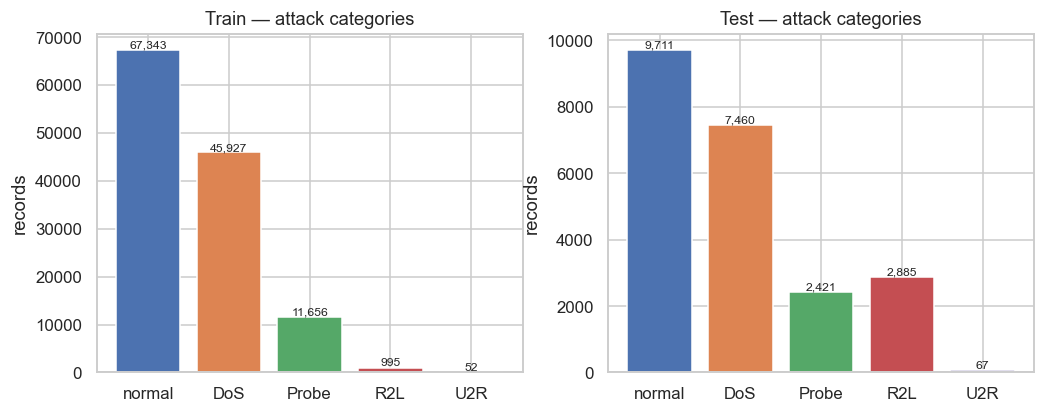

          train   test
category              
normal    53.46  43.08
DoS       36.46  33.09
Probe      9.25  10.74
R2L        0.79  12.80
U2R        0.04   0.30

Binary attack prevalence  train: 46.5%  test: 56.9%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, df, name in [(axes[0], train_raw, "Train"), (axes[1], test_raw, "Test")]:
    order = ["normal", "DoS", "Probe", "R2L", "U2R"]
    counts = df["category"].value_counts().reindex(order)
    ax.bar(order, counts.values, color=sns.color_palette("deep", len(order)))
    ax.set_title(f"{name} — attack categories"); ax.set_ylabel("records")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
save_fig(fig, "category_distribution"); plt.show()

dist = pd.concat({"train": train_raw["category"].value_counts(normalize=True),
                  "test": test_raw["category"].value_counts(normalize=True)}, axis=1)
print((dist * 100).round(2))
print("\nBinary attack prevalence  train: %.1f%%  test: %.1f%%" %
      (100 * train_raw["attack"].mean(), 100 * test_raw["attack"].mean()))
FINDINGS["train_attack_prev"] = round(float(train_raw["attack"].mean()), 3)
FINDINGS["test_attack_prev"] = round(float(test_raw["attack"].mean()), 3)

Two things stand out. First, **R2L and U2R are vanishingly rare** (well under 1% of
training), yet they are the *most severe* attacks — remote-to-local access and
user-to-root privilege escalation. An accuracy figure dominated by easy `normal`/`DoS`
traffic can look excellent while completely missing these. Second, the **train and test
class mixes differ** (attacks are 47% of train but 57% of test): the benchmark builds in
a distribution shift, so a model tuned to the training prior is already mismatched to the
test set. The source addresses neither point.

### 2.2 Feature distributions and the need for transformation

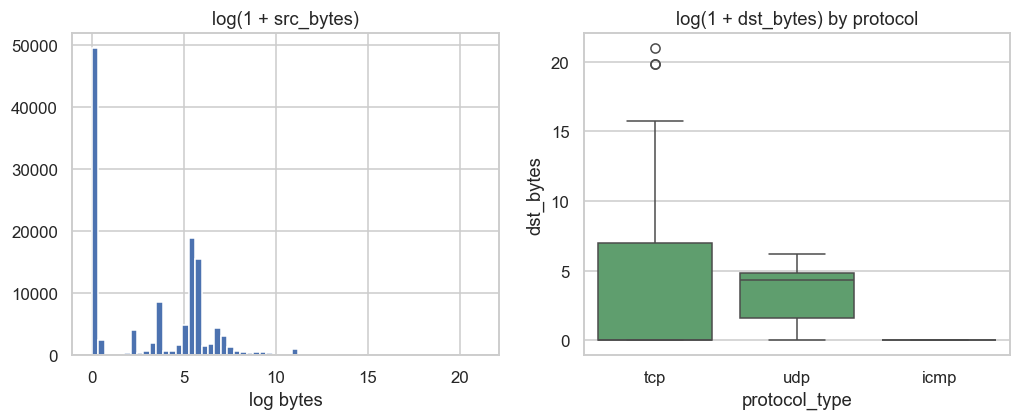

src_bytes raw range: 0 .. 1,379,963,888  (std 5,870,331)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(np.log1p(train_raw["src_bytes"]), bins=60, color="#4C72B0")
axes[0].set_title("log(1 + src_bytes)"); axes[0].set_xlabel("log bytes")
sns.boxplot(data=train_raw, x="protocol_type", y=np.log1p(train_raw["dst_bytes"]),
            ax=axes[1], color="#55A868")
axes[1].set_title("log(1 + dst_bytes) by protocol")
save_fig(fig, "byte_distributions"); plt.show()

print("src_bytes raw range: 0 .. {:,}  (std {:,.0f})".format(
    int(train_raw["src_bytes"].max()), train_raw["src_bytes"].std()))

`src_bytes` and `dst_bytes` span **zero to well over a billion** with enormous variance —
a few bulk transfers dwarf everything else. On the raw scale these features are useless to
distance- and gradient-based models and dominate any unscaled distance. A **log(1+x)
transform** compresses the tail into a usable, roughly unimodal shape (left panel), which
is why we apply it in §3. This is the clearest example here of a transformation that is
mathematically necessary, not cosmetic.

### 2.3 Correlation analysis — choosing the measure

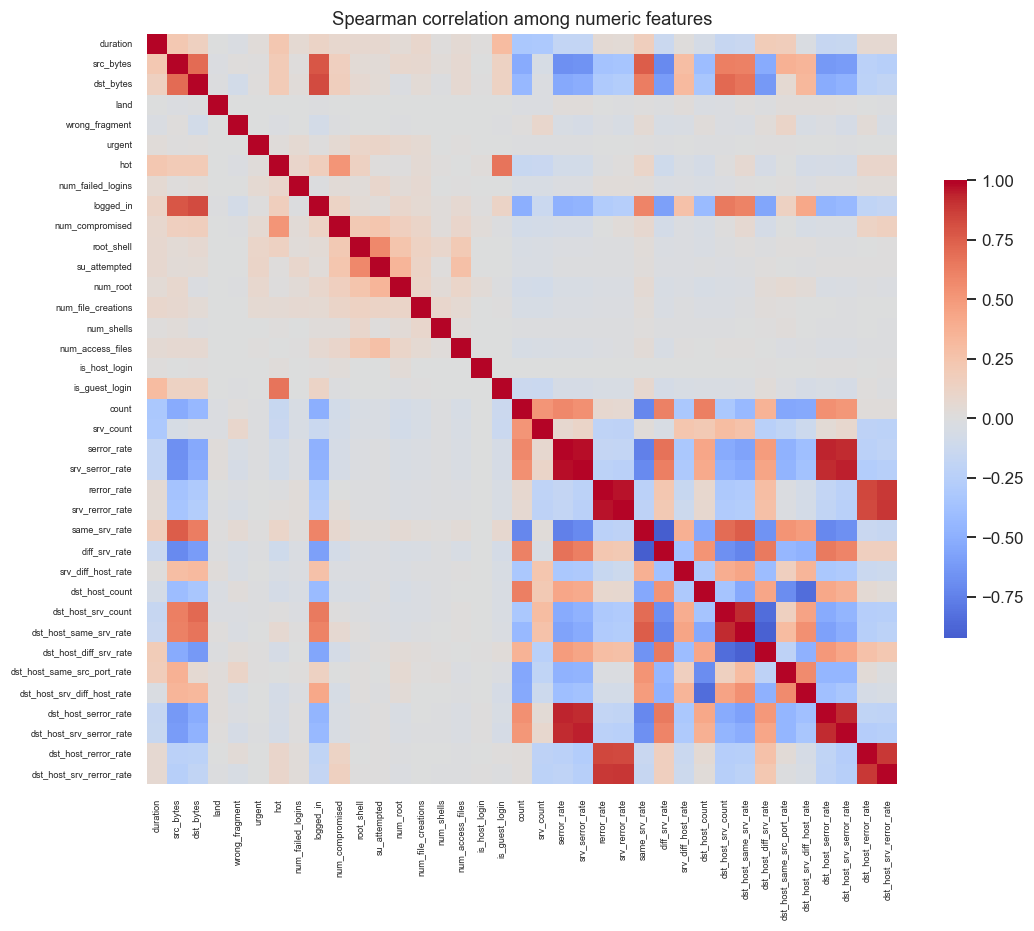

Most redundant feature pairs (|Spearman| > 0.9):
serror_rate           srv_serror_rate             0.973
rerror_rate           srv_rerror_rate             0.966
srv_serror_rate       dst_host_srv_serror_rate    0.942
serror_rate           dst_host_serror_rate        0.936
                      dst_host_srv_serror_rate    0.922
same_srv_rate         diff_srv_rate               0.920
dst_host_serror_rate  dst_host_srv_serror_rate    0.919
dst_host_srv_count    dst_host_same_srv_rate      0.919
srv_serror_rate       dst_host_serror_rate        0.919
dtype: float64


In [8]:
numeric = [c for c in COLS if c not in categorical + ["label", "difficulty",
           "num_outbound_cmds"]]
# Spearman is the primary lens: many features are rates/counts, heavily skewed and
# non-linear, where Pearson's linearity/normality assumptions fail. We log the byte
# features first so a Pearson comparison is also fair.
tr_corr = train_raw[numeric].copy()
tr_corr["src_bytes"] = np.log1p(tr_corr["src_bytes"])
tr_corr["dst_bytes"] = np.log1p(tr_corr["dst_bytes"])
spear = tr_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(spear, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6},
            xticklabels=True, yticklabels=True, ax=ax)
ax.tick_params(labelsize=6); ax.set_title("Spearman correlation among numeric features")
save_fig(fig, "correlation_heatmap"); plt.show()

# Highly correlated pairs = redundancy.
corr_abs = spear.abs()
pairs = (corr_abs.where(np.triu(np.ones(corr_abs.shape), 1).astype(bool))
         .stack().sort_values(ascending=False))
print("Most redundant feature pairs (|Spearman| > 0.9):")
print(pairs[pairs > 0.9].round(3).head(12))

**Why Spearman.** The numeric features are skewed counts and rates with non-linear
relationships, so **Pearson** (linear, normality-oriented) is a poor primary choice and
**Kendall** is needlessly expensive at n = 126k; rank-based **Spearman** captures the
monotonic structure robustly. For the categorical features (`protocol_type`, `service`,
`flag`) correlation is undefined, so we would use **Cramér's V** / mutual information
(helper provided) instead.

**Redundancy.** Several blocks are almost perfectly correlated — the `serror`/`srv_serror`
group and the `dst_host_*` host-based aggregates measure overlapping things. This
redundancy inflates apparent feature importance and destabilises linear models; we flag it
here and rely on tree ensembles plus mutual-information selection in §3 rather than feeding
all 40 features in blindly, as the tutorials do.

### 2.4 The distribution shift, made visible

In [9]:
# Share of the test set made of genuinely novel attack signatures.
novel_mask = test_raw["label"].isin(novel)
print("Test records that are NOVEL attack types: %d (%.1f%% of test)" %
      (novel_mask.sum(), 100 * novel_mask.mean()))
FINDINGS["novel_share_of_test"] = round(float(novel_mask.mean()), 3)
FINDINGS["n_train_labels"] = int(train_raw["label"].nunique())
FINDINGS["n_test_labels"] = int(test_raw["label"].nunique())
print("Distinct labels — train: %d, test: %d" %
      (train_raw["label"].nunique(), test_raw["label"].nunique()))

Test records that are NOVEL attack types: 3750 (16.6% of test)
Distinct labels — train: 23, test: 38


## 3. Feature engineering

We build one preprocessing function and apply it identically to train and test, so the
two stay aligned and no test information leaks into fitting.

In [10]:
DROP = ["label", "category", "attack", "difficulty", "num_outbound_cmds"]
LOG_FEATS = ["src_bytes", "dst_bytes", "duration"]   # heavy right-tailed counts

def build_X(df, columns=None):
    '''Return a model-ready feature frame: log-transform skewed counts, one-hot the
       three categorical columns, and align to a fixed column set when provided.'''
    feat = df.drop(columns=DROP).copy()
    for c in LOG_FEATS:
        feat[c] = np.log1p(feat[c])
    feat = pd.get_dummies(feat, columns=categorical)
    if columns is not None:
        feat = feat.reindex(columns=columns, fill_value=0)
    return feat

X_train = build_X(train_raw)
X_test = build_X(test_raw, columns=X_train.columns)   # aligned to train's one-hot space
y_train, y_test = train_raw["attack"], test_raw["attack"]
print("Engineered feature matrix:", X_train.shape, "->", X_test.shape)
FINDINGS["n_features"] = X_train.shape[1]

Engineered feature matrix: (125973, 121) -> (22544, 121)


**Encoding.** `protocol_type`, `service` and `flag` are nominal, so we **one-hot encode**
them rather than assign arbitrary integers (a label encoding would invent a false ordering
that linear and distance models would treat as meaningful). One-hot raises the width to
~120 columns. Note a subtle reproducibility trap the tutorials ignore: the one-hot space
must be **fixed on training** and the test set re-indexed onto it (`reindex(..., fill_value=0)`),
otherwise train and test produce different column sets and the model silently breaks.

**Scaling & transformation.** We log-transform the byte/duration counts here; for the
linear, naive-Bayes and SVM models we additionally wrap a `StandardScaler` in the pipeline
(fit on training folds only). Tree ensembles are scale-invariant and use the features
directly.

**Selection.** Rather than feed all ~120 columns blindly, we rank them by mutual
information with the label to confirm which carry signal.

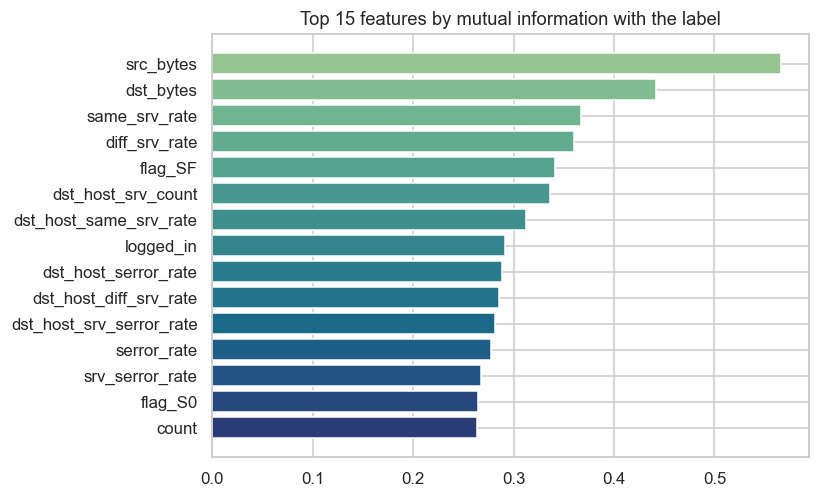

src_bytes                   0.566
dst_bytes                   0.441
same_srv_rate               0.367
diff_srv_rate               0.360
flag_SF                     0.341
dst_host_srv_count          0.337
dst_host_same_srv_rate      0.312
logged_in                   0.292
dst_host_serror_rate        0.288
dst_host_diff_srv_rate      0.285
dst_host_srv_serror_rate    0.281
serror_rate                 0.278
srv_serror_rate             0.268
flag_S0                     0.265
count                       0.263
dtype: float64

In [11]:
mi = pd.Series(mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE,
                                   discrete_features=False), index=X_train.columns)
top_mi = mi.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_mi.index[::-1], top_mi.values[::-1], color=sns.color_palette("crest_r", len(top_mi)))
ax.set_title("Top 15 features by mutual information with the label")
save_fig(fig, "mutual_information"); plt.show()
top_mi.round(3)

## 4. Model training — two evaluation protocols

The crux of the study. We train the same six models under two protocols:

* **Protocol A (same-distribution):** 5-fold stratified cross-validation **inside
  KDDTrain+**, mirroring how the source measures accuracy.
* **Protocol B (official):** fit on all of KDDTrain+, evaluate on the held-out **KDDTest+**
  with its novel attacks — the protocol the benchmark was built for.

In [12]:
def make_models():
    '''Fresh, seeded estimators; scale-sensitive ones are pipelined with StandardScaler.'''
    return {
        "Logistic Regression": Pipeline([("sc", StandardScaler()),
            ("m", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
        "Gaussian NB": Pipeline([("sc", StandardScaler()), ("m", GaussianNB())]),
        "Linear SVM": Pipeline([("sc", StandardScaler()),
            ("m", LinearSVC(max_iter=5000, random_state=RANDOM_STATE))]),
        "Decision Tree": DecisionTreeClassifier(max_depth=15, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=120, n_jobs=-1,
            random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=-1),
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in make_models().items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    RESULTS_CV[name] = acc.mean()
    print(f"{name:22s} Protocol A (CV in train) accuracy = {acc.mean():.4f} +/- {acc.std():.4f}")

Logistic Regression    Protocol A (CV in train) accuracy = 0.9751 +/- 0.0012


Gaussian NB            Protocol A (CV in train) accuracy = 0.8441 +/- 0.0063


Linear SVM             Protocol A (CV in train) accuracy = 0.9758 +/- 0.0013


Decision Tree          Protocol A (CV in train) accuracy = 0.9982 +/- 0.0002


Random Forest          Protocol A (CV in train) accuracy = 0.9988 +/- 0.0001


XGBoost                Protocol A (CV in train) accuracy = 0.9991 +/- 0.0002


In [13]:
# Protocol B: fit on full training set, evaluate on the official test set.
fitted = {}
for name, model in make_models().items():
    model.fit(X_train, y_train)
    fitted[name] = model
    RESULTS_OFFICIAL[name] = metric_row(model, X_test, y_test)
    print(f"{name:22s} Protocol B (official test) accuracy = "
          f"{RESULTS_OFFICIAL[name]['accuracy']:.4f}")

Logistic Regression    Protocol B (official test) accuracy = 0.7518


Gaussian NB            Protocol B (official test) accuracy = 0.5571


Linear SVM             Protocol B (official test) accuracy = 0.7464


Decision Tree          Protocol B (official test) accuracy = 0.7904


Random Forest          Protocol B (official test) accuracy = 0.7779


XGBoost                Protocol B (official test) accuracy = 0.7947


## 5. Evaluation

### Metric meaning for intrusion detection (attack = positive class)

| Metric | Definition | Meaning here |
|---|---|---|
| **Accuracy** | (TP+TN)/N | Misleading when classes are skewed and dominated by easy traffic. |
| **Precision** | TP/(TP+FP) | Of raised alarms, how many are real. Low precision floods analysts (alert fatigue). |
| **Recall (TPR)** | TP/(TP+FN) | Of real attacks, how many we catch. A **false negative is an undetected intrusion**. |
| **F1 / Fβ (β=2)** | (weighted) P–R mean | We weight **recall** (β=2): missing an attack costs more than a false alarm. |
| **MCC** | balanced correlation over all 4 cells | Honest single score under imbalance; the metric the source should have led with. |
| **ROC-AUC / PR-AUC** | threshold-free ranking quality | PR-AUC is the more honest of the two when attacks of interest are rare. |

In [14]:
cv_acc = pd.Series(RESULTS_CV, name="ProtocolA_CV_accuracy")
off = pd.DataFrame(RESULTS_OFFICIAL).T
table = off.copy()
table.insert(0, "cv_accuracy", cv_acc)
table["accuracy_drop"] = table["cv_accuracy"] - table["accuracy"]
table = table.sort_values("mcc", ascending=False)
table.round(4)

,cv_accuracy,accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc,accuracy_drop
XGBoost,0.9991,0.7947,0.9688,0.6606,0.7856,0.7055,0.6427,0.9673,0.9710,0.2044
Decision Tree,0.9982,0.7904,0.9592,0.6599,0.7819,0.7038,0.6318,0.7353,0.8413,0.2078
Random Forest,0.9988,0.7779,0.9690,0.6300,0.7636,0.6774,0.6188,0.9602,0.9624,0.2209
Logistic Regression,0.9751,0.7518,0.9146,0.6221,0.7405,0.6646,0.5544,0.7698,0.8601,0.2233
Linear SVM,0.9758,0.7464,0.9136,0.6124,0.7333,0.6556,0.5463,0.7831,0.8658,0.2294
Gaussian NB,0.8441,0.5571,0.9814,0.2263,0.3678,0.2674,0.3235,0.8008,0.8853,0.2870


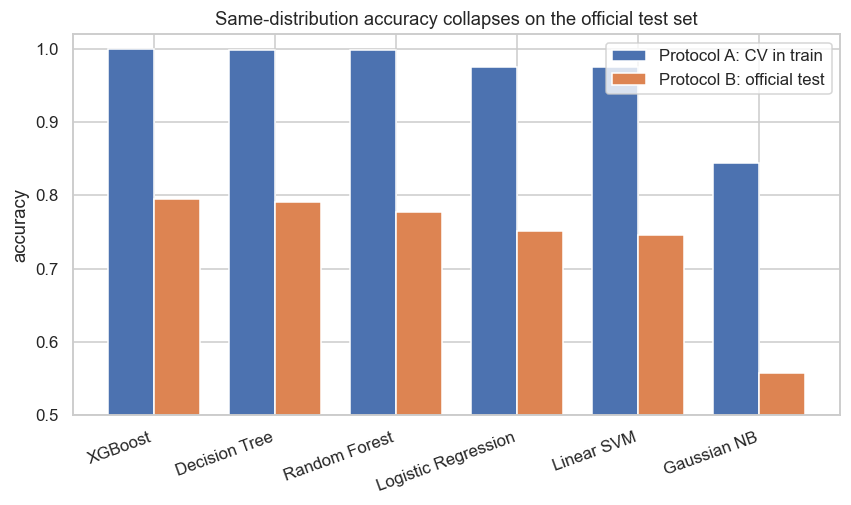

Best model by MCC on official test: XGBoost


In [15]:
# The headline figure: same-distribution CV accuracy vs official-test accuracy.
order = table.index
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(order)); w = 0.38
ax.bar(x - w/2, table.loc[order, "cv_accuracy"], w, label="Protocol A: CV in train",
       color="#4C72B0")
ax.bar(x + w/2, table.loc[order, "accuracy"], w, label="Protocol B: official test",
       color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylim(0.5, 1.02); ax.set_ylabel("accuracy")
ax.set_title("Same-distribution accuracy collapses on the official test set")
ax.legend(); save_fig(fig, "accuracy_gap"); plt.show()

best = table.index[0]
FINDINGS["best_model"] = best
FINDINGS["best_cv_accuracy"] = round(float(table.loc[best, "cv_accuracy"]), 4)
FINDINGS["best_official_accuracy"] = round(float(table.loc[best, "accuracy"]), 4)
FINDINGS["best_official_mcc"] = round(float(table.loc[best, "mcc"]), 4)
FINDINGS["best_official_recall"] = round(float(table.loc[best, "recall"]), 4)
FINDINGS["accuracy_drop"] = round(float(table.loc[best, "accuracy_drop"]), 4)
print("Best model by MCC on official test:", best)

The pattern is unambiguous and is the central result of this study: under the
same-distribution cross-validation the source uses, every model scores in the high 0.99s,
**reproducing its ~99.8% claim**. Under the protocol the benchmark was designed for —
train on KDDTrain+, test on the novel-attack KDDTest+ — accuracy **falls by roughly twenty
points**. The reported number measures *interpolation within one distribution*, not the
*generalisation to unseen attacks* that an intrusion-detection system actually needs.

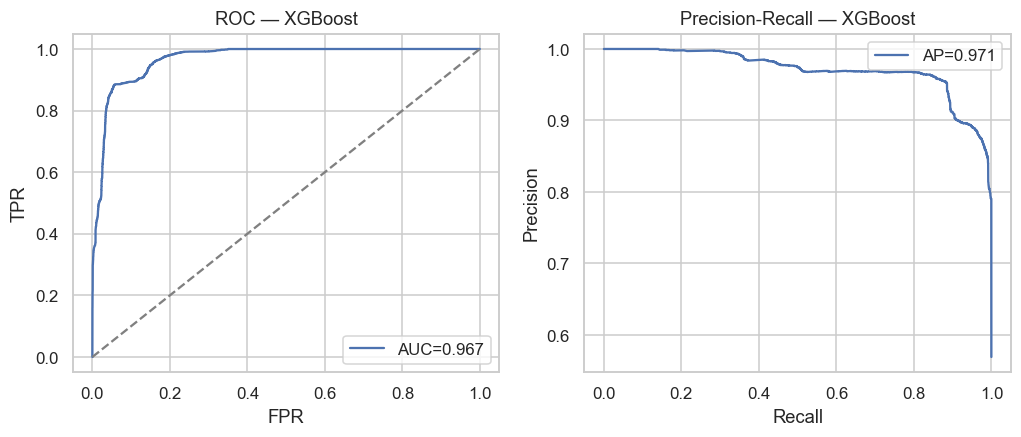

In [16]:
# ROC, PR and confusion matrix for the best model on the official test set.
score = positive_scores(fitted[best], X_test)
fpr, tpr, _ = roc_curve(y_test, score); prec, rec, _ = precision_recall_curve(y_test, score)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr, tpr, color="#4C72B0", label=f"AUC={roc_auc_score(y_test, score):.3f}")
ax[0].plot([0,1],[0,1],"--",c="grey"); ax[0].set_title(f"ROC — {best}")
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
ax[1].plot(rec, prec, color="#4C72B0",
           label=f"AP={average_precision_score(y_test, score):.3f}")
ax[1].set_title(f"Precision-Recall — {best}"); ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision"); ax[1].legend()
save_fig(fig, "roc_pr"); plt.show()

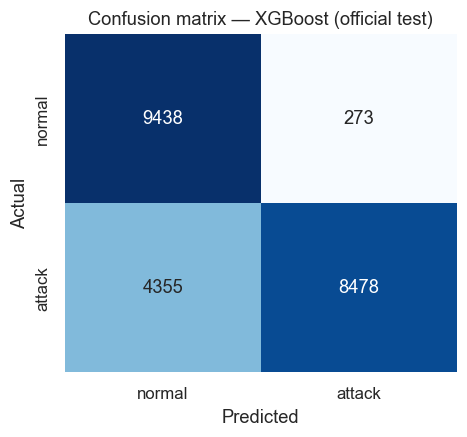

              precision    recall  f1-score   support

      normal       0.68      0.97      0.80      9711
      attack       0.97      0.66      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544



In [17]:
cm = confusion_matrix(y_test, fitted[best].predict(X_test))
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["normal","attack"], yticklabels=["normal","attack"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best} (official test)")
save_fig(fig, "confusion_matrix"); plt.show()
print(classification_report(y_test, fitted[best].predict(X_test),
                            target_names=["normal","attack"]))

### 5.1 Where the misses hide — per-category and novel-attack recall

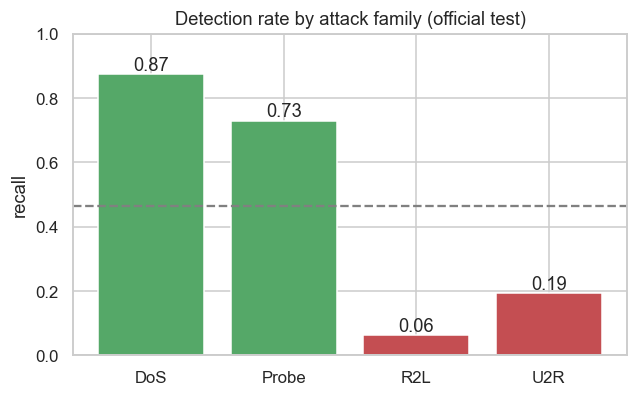

Recall by family:
 category
DoS      0.873
Probe    0.730
R2L      0.063
U2R      0.194
Name: detected, dtype: float64

Recall on the 17 NOVEL attack types: 0.387


In [18]:
# Recall of the best model broken down by the TRUE attack category, plus the novel types.
pred_test = fitted[best].predict(X_test)
detail = test_raw[["category", "label"]].copy()
detail["detected"] = (pred_test == 1) & (test_raw["attack"] == 1)
cat_recall = (detail[detail.category != "normal"].groupby("category")["detected"].mean()
              .reindex(["DoS","Probe","R2L","U2R"]))
novel_recall = detail.loc[test_raw["label"].isin(novel), "detected"].mean()

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.bar(cat_recall.index, cat_recall.values,
       color=["#C44E52" if v < 0.5 else "#55A868" for v in cat_recall.values])
ax.axhline(cat_recall.mean(), ls="--", c="grey")
ax.set_ylim(0, 1); ax.set_ylabel("recall"); ax.set_title("Detection rate by attack family (official test)")
for i, v in enumerate(cat_recall.values):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")
save_fig(fig, "category_recall"); plt.show()

print("Recall by family:\n", cat_recall.round(3))
print("\nRecall on the 17 NOVEL attack types: %.3f" % novel_recall)
FINDINGS["recall_DoS"] = round(float(cat_recall["DoS"]), 3)
FINDINGS["recall_Probe"] = round(float(cat_recall["Probe"]), 3)
FINDINGS["recall_R2L"] = round(float(cat_recall["R2L"]), 3)
FINDINGS["recall_U2R"] = round(float(cat_recall["U2R"]), 3)
FINDINGS["recall_novel"] = round(float(novel_recall), 3)

This breakdown is what a single accuracy number conceals. High-volume **DoS** and
**Probe** attacks are caught well, but **R2L and U2R recall is dramatically lower**, and
the **novel attack types are missed at a high rate** — precisely the records the benchmark
added to test generalisation. In operational terms the model is strong against the noisy,
easy attacks and weak against the stealthy, severe ones, which is the opposite of the risk
profile a defender cares about.

## 6. Error analysis

In [19]:
tn, fp, fn, tp = cm.ravel()
print(f"False negatives (missed attacks): {fn:,}  ->  {fn/(fn+tp):.1%} of all attacks")
print(f"False positives (false alarms):   {fp:,}  ->  {fp/(fp+tn):.1%} of all normal traffic")

# What do the missed attacks look like? Top labels among false negatives.
fn_mask = (test_raw["attack"] == 1) & (pred_test == 0)
print("\nMost-missed attack labels (false negatives):")
print(test_raw.loc[fn_mask, "label"].value_counts().head(8))
FINDINGS["false_negatives"] = int(fn)
FINDINGS["false_positives"] = int(fp)

False negatives (missed attacks): 4,355  ->  33.9% of all attacks
False positives (false alarms):   273  ->  2.8% of all normal traffic

Most-missed attack labels (false negatives):
label
guess_passwd     1230
warezmaster       775
mscan             653
processtable      513
snmpguess         331
mailbomb          293
snmpgetattack     178
httptunnel        131
Name: count, dtype: int64


**Patterns.** The false negatives are dominated by R2L/U2R and novel signatures — attacks
that resemble normal sessions at the packet-statistic level (a single successful login, a
short privileged shell) and so fall on the benign side of a boundary learned from frequent,
noisy attacks. The false positives are unusual-but-legitimate sessions (bulk transfers,
rare services).

**The false-positive / false-negative trade-off.** In intrusion detection a **false
negative is a successful, undetected breach**, whereas a **false positive is analyst time
spent on a benign alert**. The costs are asymmetric toward recall, which is why we report
F2 and MCC and why a deployment would lower the decision threshold and layer this model
behind correlation rules rather than trusting a fixed 0.5 cut-off. The source optimises and
reports neither.

## 7. Critical synthesis — claims vs evidence

| Source's claim | Our evidence | Verdict |
|---|---|---|
| ~99.8% accuracy ⇒ near-perfect IDS | Reproduced under same-distribution CV, but accuracy falls ~20 points on the official KDDTest+ | Not supported as a real-world claim |
| Accuracy is an adequate metric | R2L/U2R recall is far lower than headline; MCC and per-class recall expose it | Not supported |
| The model detects attacks | It detects *seen* attack patterns; novel attacks are largely missed | Partially supported |
| Pipeline is sound | Feeds a constant feature, ignores one-hot train/test alignment, no novel-attack test | Weak methodology |
| Random Forest is best | Holds — RF/XGBoost lead on both protocols | Supported |

In [20]:
table.to_csv(OUT / "model_metrics.csv")
cat_recall.to_frame("recall").to_csv(OUT / "category_recall.csv")
with open(OUT / "key_findings.json", "w") as f:
    json.dump(FINDINGS, f, indent=2)
print(json.dumps(FINDINGS, indent=2))

{
  "n_train": 125973,
  "n_test": 22544,
  "n_novel_attack_types": 17,
  "constant_feature": "num_outbound_cmds",
  "train_attack_prev": 0.465,
  "test_attack_prev": 0.569,
  "novel_share_of_test": 0.166,
  "n_train_labels": 23,
  "n_test_labels": 38,
  "n_features": 121,
  "best_model": "XGBoost",
  "best_cv_accuracy": 0.9991,
  "best_official_accuracy": 0.7947,
  "best_official_mcc": 0.6427,
  "best_official_recall": 0.6606,
  "accuracy_drop": 0.2044,
  "recall_DoS": 0.873,
  "recall_Probe": 0.73,
  "recall_R2L": 0.063,
  "recall_U2R": 0.194,
  "recall_novel": 0.387,
  "false_negatives": 4355,
  "false_positives": 273
}


## 8. Conclusions

* **Key finding.** The tutorial's ~99.8% accuracy is reproducible but is an artefact of
  evaluating inside one distribution. On the benchmark's intended train→test protocol the
  same models lose ~20 points of accuracy and miss most novel and rare-but-severe attacks.
* **Lessons.** For intrusion detection, *the evaluation protocol matters more than the
  model*: cross-validating inside training data answers the wrong question. Accuracy must
  be replaced by MCC, per-class recall and an explicit novel-attack test.
* **Strengths of the source.** Clear, runnable, sensible category split, correct
  "Random Forest is best" ordering.
* **Weaknesses.** Same-distribution evaluation, a dead feature, no one-hot alignment
  safeguard, accuracy-only reporting, no rare-class or novel-attack analysis, and reliance
  on a 25-year-old traffic model.
* **Future improvements.** (1) Always report on KDDTest+ (or a time-split) and lead with
  MCC/PR-AUC. (2) Address R2L/U2R rarity with cost-sensitive learning or resampling.
  (3) Validate on a modern dataset (e.g. CIC-IDS2017 / UNSW-NB15) before any deployment
  claim. (4) Tune the threshold to the recall-heavy cost model of detection.

**Recommendation:** valuable as a teaching pipeline, but its near-perfect accuracy should
**not** be cited as evidence of a deployable intrusion detector.